## Часть 1: Проверка гипотезы о различии средней активности пользователей Москвы и Санкт-Петербурга в сервисе Яндекс Книги

## Цели и задачи проекта

**Цель проекта** - найти статистическое подтверждение гипотезы, что среднее время активности пользователей в Санкт-Петербурге больше, чем в Москве

**Задачи проекта**
- Загрузить данные и ознакомиться с ними
- Провести предобработку данных
- Проверить дизайн эксперимента
- Расчитать исследуемую метрику
- Проверить гипотезу с помощью статистического теста
- Написать выводы по результату A/B - тестирования

## Содержимое проекта

1. Загрузка данных и знакомство с ними
- 1.1 Предобработка данных
- 1.2 Проверка дизайна эксперимента
2. Проверка гипотезы
3. Аналитическая записка
---

## 1. Загрузка данных и знакомство с ними

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu

from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower

from statsmodels.stats.proportion import proportions_ztest

Загружаем данные, сохраняем в переменной `books_df`

In [2]:
books_df = pd.read_csv('/datasets/yandex_knigi_data.csv')

Познакомимся с данными с помощью методов `info()` и `head()` - выведем общую информацию и первые строки датафрейма

In [3]:
books_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


In [4]:
books_df.head()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


В результате ознакомления с датасетом `books_df` выявлено:
* Датасет `books_df` содержит **8784** строк и **4** столбца
* Названия столбцов приведены к общему стилю
* Данные хранятся в корректных типах данных
* Во всех столбцах **отсутствуют пропуски**
* Данные для анализа представлены корректно

### Предобработка данных

#### Проверим данные на наличие дубликатов

In [5]:
# Выведем количество уникальных значений каждого столбца
display(books_df.nunique())

Unnamed: 0    8784
city             2
puid          8540
hours         8024
dtype: int64

In [6]:
# Проверим есть ли повторяющиеся сроки
duplicates = books_df[books_df.duplicated(subset=['city', 'puid', 'hours'], keep=False)]
display(duplicates)

,Unnamed: 0,city,puid,hours


В ходе проверки выявлено **отсутствие дублирующихся строк**. Столбец `city` содержит два значения - проверим, что для анализа выгружены верные города.

In [7]:
# Проверим что в выгрузке нужные города
display(books_df['city'].unique())

array(['Москва', 'Санкт-Петербург'], dtype=object)

#### Проверка на аномалии и выбросы

Для проверки аномалий построим гистограмму по столбцу `hours`.

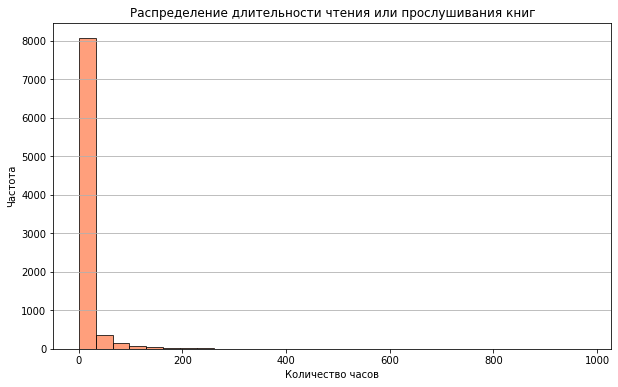

In [8]:
plt.figure(figsize=(10, 6))

# Строим гистограмму с помощью pandas через plot(kind='hist')
books_df['hours'].plot(
                kind='hist', # Тип графика — гистограмма
                bins=30, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                color='coral'
)

# Настраиваем оформление графика
plt.title('Распределение длительности чтения или прослушивания книг')
plt.xlabel('Количество часов')
plt.ylabel('Частота')

# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show() 

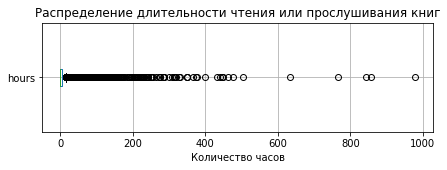

In [9]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
books_df.boxplot(column='hours', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение длительности чтения или прослушивания книг')
plt.xlabel('Количество часов')

# Выводим график
plt.show()

На диаграмме видно правостороннее распределение с длинным хвостом, где аномальные значения наблюдаются в интервале примерно от 150 до 1000. На диаграмме размаха выбросы заметны еще сильнее. 

Можно предположить, что в данных могли произойти технические ошибки при фиксировании длительности чтения книг, но также не будем исключать, что отдельные пользователи действительно могли проводить за чтением большее время.

Для дальнейшего анализа оставим значения, которые будут меньше или равны 99-го процентилю. Это поможет убрасть часть аномальных значений, но не исказит общую картину данных

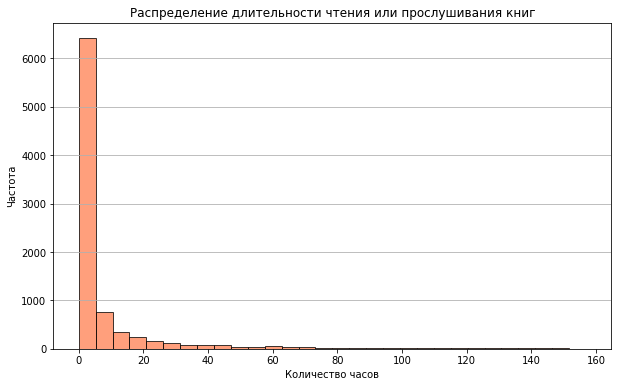

In [10]:
cleaned_hours = books_df[books_df['hours'] <= books_df['hours'].quantile(0.99)]['hours']

plt.figure(figsize=(10, 6))

# Строим гистограмму с помощью pandas через plot(kind='hist')
cleaned_hours.plot(
                kind='hist', # Тип графика — гистограмма
                bins=30, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                color='coral'
)

# Настраиваем оформление графика
plt.title('Распределение длительности чтения или прослушивания книг')
plt.xlabel('Количество часов')
plt.ylabel('Частота')

# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show() 

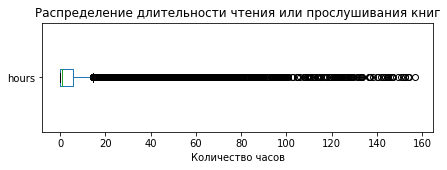

In [11]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
cleaned_hours.plot.box(vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение длительности чтения или прослушивания книг')
plt.xlabel('Количество часов')

# Выводим график
plt.show()

In [12]:
# Оставим значения меньше или равные 99-го процентилю

books_df = books_df[books_df['hours'] <= books_df['hours'].quantile(0.99)]

### Проверка дизайна эксперимента

In [13]:
# Находим количество уникальных пользователей в Москве
group_msc = books_df[books_df['city'] == 'Москва']['puid'].nunique() 

# Находим количество уникальных пользователей в Санкт-Петербурге
group_spb = books_df[books_df['city'] == 'Санкт-Петербург']['puid'].nunique()

display(f'Москва: {group_msc} пользователей, Санкт-Петербург: {group_spb} пользователей')

'Москва: 6171 пользователей, Санкт-Петербург: 2525 пользователей'

In [14]:
# Считаем процентную разницу в количестве пользователей в городах по формуле, где abs - это модуль, опускающий знак разницы
percentage_diff = 100 * abs(group_msc - group_spb) / group_msc

display(f'Процентная разница в количестве пользователей в городах: {round(percentage_diff, 2)}%')

'Процентная разница в количестве пользователей в городах: 59.08%'

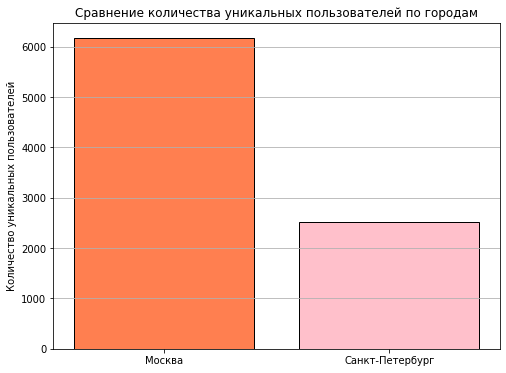

In [15]:
# Строим столбчатую диаграмму для визуализации различия между группами
plt.figure(figsize=(8, 6))

groups = ['Москва', 'Санкт-Петербург']
counts = [group_msc, group_spb]

plt.bar(groups, counts, color=['coral', 'pink'], edgecolor='black')
plt.ylabel('Количество уникальных пользователей')
plt.title('Сравнение количества уникальных пользователей по городам')
plt.grid(axis='y')

plt.show()

**Процентное расхождение в количестве уникальных пользователей между Москвой и Санкт-Петербургом составляет 59,08%**. Разница в количестве пользователей может повлиять на результаты тестирования. Это стоит учитывать при анализе

Проверим пользователей, которые могли оказаться в обеих группах одновременно

In [16]:
group_msc = books_df[books_df['city'] == 'Москва']['puid']
group_spb = books_df[books_df['city'] == 'Санкт-Петербург']['puid']

intersection = list(set(group_msc) & set(group_spb))

display(f'Пользователи одновременно в Москве и Санкт-Петербурге: {intersection}')

'Пользователи одновременно в Москве и Санкт-Петербурге: [439054848, 98068993, 84978689, 331188228, 59679749, 790564870, 40698887, 162106378, 1078819852, 1684058125, 1130000018954257, 959563282, 571554323, 1358054932, 313990163, 1778617878, 1210363415, 1316543509, 649885721, 1183963675, 1395494429, 1314529823, 1145886241, 1593760291, 1725564965, 24138278, 520518182, 363351088, 108083761, 570189363, 584447544, 860187201, 309104707, 550835780, 441112643, 1977784899, 1406501962, 528250442, 103543372, 1616171597, 589188176, 989693522, 1958805587, 401065555, 1557916755, 429727314, 1130000028554332, 488154206, 1965288031, 10597984, 9979490, 301108324, 767485035, 453988975, 912829040, 955554416, 1672056947, 819309176, 10815097, 196683896, 1076879993, 1974615673, 531369086, 258809476, 66998918, 360290950, 1085783174, 236601993, 359740041, 998045836, 888840333, 2019864206, 1109631631, 1713008273, 317826707, 1236880533, 46837910, 1166679702, 137198745, 1891219106, 987817124, 1735154341, 176447657

In [17]:
# Удалим этих пользователей
books_df = books_df[~books_df['puid'].isin(intersection)]

In [18]:
# Находим количество уникальных пользователей в Москве
group_msc = books_df[books_df['city'] == 'Москва']['puid'].nunique() 

# Находим количество уникальных пользователей в Санкт-Петербурге
group_spb = books_df[books_df['city'] == 'Санкт-Петербург']['puid'].nunique()

display('Количество пользователей после предобработки данных:')
display(f'Москва: {group_msc} пользователей, Санкт-Петербург: {group_spb} пользователей')

'Количество пользователей после предобработки данных:'

'Москва: 5934 пользователей, Санкт-Петербург: 2288 пользователей'

Проверим как поменялось соотношение пользователей по городам

In [19]:
# Считаем процентную разницу в количестве пользователей в городах по формуле, где abs - это модуль, опускающий знак разницы
percentage_diff = 100 * abs(group_msc - group_spb) / group_msc

display(f'Процентная разница в количестве пользователей в городах: {round(percentage_diff, 2)}%')

'Процентная разница в количестве пользователей в городах: 61.44%'

In [20]:
100 * books_df[books_df['city'] == 'Москва']['puid'].nunique() / books_df['puid'].nunique(), 100 * books_df[books_df['city'] == 'Санкт-Петербург']['puid'].nunique() / books_df['puid'].nunique()

(72.17222087083435, 27.827779129165652)

In [21]:
# Выведем количество пользователей и среднее время прослушиваний по городам
grouped_books_df = books_df.groupby('city').agg({'puid':'nunique', 'hours':'mean'})

display(grouped_books_df)

,puid,hours
city,,
Москва,5934,8.089960
Санкт-Петербург,2288,8.438326


## 2. Проверка гипотезы

Гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [22]:
# Фильтруем данные, оставляем только пользователей из Москвы
group_msc = books_df[books_df['city'] == 'Москва']

# Считаем среднюю длительность прослушиваний и чтения в Москве
avg_activity_msc_per_user = group_msc.groupby('puid')['hours'].mean() # для пользователя
avg_activity_msc = round(avg_activity_msc_per_user.mean(), 2)  # общая для Мск 

display(f'Средняя активность пользователей из Москвы в часах: {avg_activity_msc}')

'Средняя активность пользователей из Москвы в часах: 8.09'

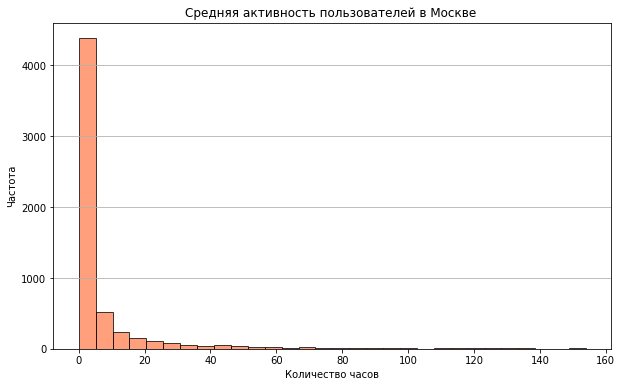

In [23]:
plt.figure(figsize=(10, 6))

# Строим гистограмму с помощью pandas через plot(kind='hist')
avg_activity_msc_per_user.plot(
                kind='hist', # Тип графика — гистограмма
                bins=30, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                color='coral'
)

# Настраиваем оформление графика
plt.title('Средняя активность пользователей в Москве ')
plt.xlabel('Количество часов')
plt.ylabel('Частота')

# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show()

In [24]:
# Фильтруем данные, оставляем только пользователей из Санкт-Петербурга
group_spb = books_df[books_df['city'] == 'Санкт-Петербург']

# Считаем среднюю длительность прослушиваний и чтения в Санкт-Петербурге
avg_activity_spb_per_user = group_spb.groupby('puid')['hours'].mean()  # для пользователя
avg_activity_spb = round(avg_activity_spb_per_user.mean(), 2)  # общая для СПб

display(f'Средняя активность пользователей из Санкт-Петербурга в часах: {avg_activity_spb}')

'Средняя активность пользователей из Санкт-Петербурга в часах: 8.44'

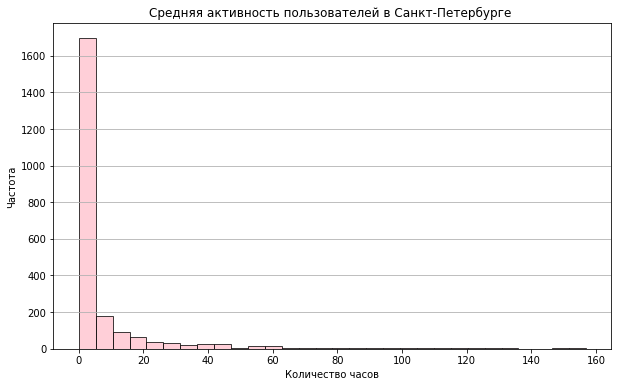

In [25]:
plt.figure(figsize=(10, 6))

# Строим гистограмму с помощью pandas через plot(kind='hist')
avg_activity_spb_per_user.plot(
                kind='hist', # Тип графика — гистограмма
                bins=30, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                color='pink'
)

# Настраиваем оформление графика
plt.title('Средняя активность пользователей в Санкт-Петербурге ')
plt.xlabel('Количество часов')
plt.ylabel('Частота')

# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show()

In [26]:
rel_diff_avg_activity = round((avg_activity_spb - avg_activity_msc)*100, 2)

display(f'Разница в показателе успешного числа сессий составляет {rel_diff_avg_activity} %')

'Разница в показателе успешного числа сессий составляет 35.0 %'

На гистограммах средней активности пользователей Москвы и Санкт-Петербурга наблюдается **правосторонее распределение данных, с длинным хвостом, отличное от нормального**. Также стоит учитывать **разницу численности выборок** по городам. В связи с этим, для анализа следует использовать **U-тест Манна-Уитни**

Уровень статистической значимости выберем стандартный **alpha = 0.05**

In [27]:
# Проводим тест Манна-Уитни
alpha = 0.05
mw_test = mannwhitneyu(
    avg_activity_msc_per_user, # Выборка значений метрики для Мск
    avg_activity_spb_per_user, # Выборка значений метрики для СПб
    alternative='less') # Выбираем одностороннюю гипотезу Мск < СПб


if mw_test.pvalue > alpha:
    print(f'pvalue={round(mw_test.pvalue,4)} > {alpha}')
    print('Нулевая гипотеза находит подтверждение. Распределения метрики в группах Мск и СПб равны')
else:
    print(f'pvalue={round(mw_test.pvalue,4)} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения. Распределения метрики в группах Мск и СПб различаются')

pvalue=0.4256 > 0.05
Нулевая гипотеза находит подтверждение. Распределения метрики в группах Мск и СПб равны


## 3. Аналитическая записка

#### Вывод по результатам A/B-тестирования

Для проверки гипотезы о том, что пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы, был проведен A/B-тест с участием **группы пользователей из Москвы (5934 пользователей) и группы пользователей из Санкт-Петербурга (2288 пользователей)**. **Процентная разница в количестве пользователей в городах составила 61.44%**. В качестве **целевой метрики** выбрано **увеличение среднего времени активности пользователей из Санкт-Петкрбурга по сравнению со среднем временем активности пользователей из Москвы. В качестве **статистического теста для проверки результатов A/B-тестирования выбран U-тест Манна-Уитни**.

Значение **p-value оказалось больше значения уровня статистической значимости, и равно 0.4256**, поэтому в рамках текущего эксперимента мы **не имеем достаточных оснований для отклонения нулевой гипотезы**. Это означает, что на текущих данных **не обнаружено статистически значимого различия между группами пользователей из Санкт-Петербурга и Москвы**. 

Разница в объеме выборок составляет более 61%. Если истинный эффект (различие) между городами очень слабый, тесту могло «не хватить сил» его заметить при таком соотношении объемов. Стоит добавить, что у жителей этих городов схожий образ жизни и бытовые привычки (паттерны поведения) и это помогает логично объяснить результаты

----

## Часть 2: Анализ данных интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни.

## 1. Цели и задачи исследования.

**Цель проекта** - найти статистическое подтверждение гипотезы, что упрощение интерфейса сайта приведет к увеличению конверсии зарегистрированных пользователей в покупателей в течение семи дней после регистрации в системе как минимум на три процентных пункта

**Задачи проекта**
- Загрузить данные и ознакомиться с ними
- Провести предобработку данных
- Проверить дизайн эксперимента
- Расчитать исследуемую метрику
- Проверить гипотезу с помощью статистического теста
- Написать выводы по результату A/B - тестирования

## 2. Загрузка и знакомство с данными.


In [29]:
# Загружаем данные, сохраняем в переменные
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [30]:
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [31]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


В результате ознакомления с датасетом `participants` выявлено:
* Датасет `participants` содержит **14525** строк и **4** столбца
* Названия столбцов приведены к общему стилю
* Данные хранятся в корректных типах данных
* Во всех столбцах **отсутствуют пропуски**
* Данные для анализа представлены корректно

In [32]:
events.head()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [33]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


В результате ознакомления с датасетом `events` выявлено:
* Датасет `events` содержит **787286** строк и **4** столбца
* Названия столбцов приведены к общему стилю
* Данные хранятся в корректных типах данных
* **Пропуски присутствуют только в столбце `details`**
* Данные для анализа представлены корректно

Соединим данные в один датасет `interface_df`, используя тип присоединения `left` в параметре `how`, чтобы в объединенном датасете оказались данные о всех пользователях, учавствующих в A/B-тестировании.

In [34]:
interface_df = participants.merge(events, on='user_id', how='left')

In [35]:
interface_df.head()

,user_id,group,ab_test,device,event_dt,event_name,details
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38
1,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:49,login,NaN
2,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:57,login,NaN
3,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:38:54,login,NaN
4,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-08 22:15:35,login,NaN


In [36]:
interface_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 104558 entries, 0 to 104557
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     104558 non-null  object        
 1   group       104558 non-null  object        
 2   ab_test     104558 non-null  object        
 3   device      104558 non-null  object        
 4   event_dt    104558 non-null  datetime64[ns]
 5   event_name  104558 non-null  object        
 6   details     27878 non-null   object        
dtypes: datetime64[ns](1), object(6)
memory usage: 6.4+ MB


В полученном датасете `interface_df` :
* Содержится **104558** строк и **7** столбцов
* Названия столбцов приведены к общему стилю
* Данные хранятся в корректных типах данных
* **Пропуски присутствуют только в столбце `details`**
* Данные для анализа представлены корректно

### Предобработка данных

Нам необходимо проверить результаты A/B-теста `interface_eu_test`, поэтому оставим данные только по соответствующим участникам, чтобы оптимизировать обработку данных

In [37]:
# Отфильтруем данные, по столбцу ab_test оставим только значения interface_eu_test
interface_df = interface_df[interface_df['ab_test']=='interface_eu_test']

In [38]:
interface_df.info()

# Количество строк итогового датафрейма
lens_of_start = len(interface_df)
display(f'Количество строк датафрейма после фильтрации: {lens_of_start}')

<class 'pandas.core.frame.DataFrame'>
Int64Index: 79715 entries, 0 to 104557
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     79715 non-null  object        
 1   group       79715 non-null  object        
 2   ab_test     79715 non-null  object        
 3   device      79715 non-null  object        
 4   event_dt    79715 non-null  datetime64[ns]
 5   event_name  79715 non-null  object        
 6   details     21075 non-null  object        
dtypes: datetime64[ns](1), object(6)
memory usage: 4.9+ MB


'Количество строк датафрейма после фильтрации: 79715'

#### Наличие пропущенных значений

In [39]:
nan = round(interface_df['details'].isna().mean(), 2)
display(f'Доля пропущенных значений в столбце details: {nan}')

'Доля пропущенных значений в столбце details: 0.74'

Пропуски в столбце `details` относятся к типу MCAR, и их нельзя восстановить из имеющихся данных. Так как данные столбца `details` не повлияют на основную метрику исследования, и доля пропусков большая - оставим пропущенные значения без изменений.

#### Наличие явных и неявных дубликатов

In [40]:
# Проверим наличие полных дубликатов в датафрейме interface_df
interface_df.duplicated().sum()

6170

In [41]:
# Удалим явные дубликаты, оставив только уникальные значения
interface_df = interface_df.drop_duplicates(subset=None, keep='first')

In [42]:
# Выведем количество уникальных значений каждого столбца
display(interface_df.nunique())

user_id       10850
group             2
ab_test           1
device            4
event_dt      66373
event_name        5
details          99
dtype: int64

In [43]:
# Выведем значения столбцов с небольшим числом уникальных значений
for column in ['group', 'ab_test', 'device', 'event_name']:
    display(f'Уникальные значения в столбце {column}:')
    display(interface_df[column].sort_values().unique())
    display()

'Уникальные значения в столбце group:'

array(['A', 'B'], dtype=object)

'Уникальные значения в столбце ab_test:'

array(['interface_eu_test'], dtype=object)

'Уникальные значения в столбце device:'

array(['Android', 'Mac', 'PC', 'iPhone'], dtype=object)

'Уникальные значения в столбце event_name:'

array(['login', 'product_cart', 'product_page', 'purchase',
       'registration'], dtype=object)

In [44]:
# Проверим есть ли в датафрейме дублирующиеся события пользователей
duplicates = interface_df[interface_df.duplicated(subset=['user_id', 'event_dt', 'event_name'], keep=False)]
display(duplicates)

,user_id,group,ab_test,device,event_dt,event_name,details
1282,037950232631042E,B,interface_eu_test,PC,2020-12-24 19:28:04,purchase,499.89
1283,037950232631042E,B,interface_eu_test,PC,2020-12-24 19:28:04,purchase,99.99
1576,042E53F44C6DB24B,B,interface_eu_test,Android,2020-12-23 08:57:24,purchase,4.99
1577,042E53F44C6DB24B,B,interface_eu_test,Android,2020-12-23 08:57:24,purchase,9.89
1897,04CB640A250E1E21,B,interface_eu_test,iPhone,2020-12-27 05:44:29,purchase,4.49
...,...,...,...,...,...,...,...
103920,FE3A480DAA0A7EB4,B,interface_eu_test,PC,2020-12-27 03:38:31,purchase,4.49
104302,FF1AF3B4FB596E23,B,interface_eu_test,iPhone,2020-12-14 13:01:23,purchase,9.99
104303,FF1AF3B4FB596E23,B,interface_eu_test,iPhone,2020-12-14 13:01:23,purchase,4.99
104425,FF827554725859E2,A,interface_eu_test,Mac,2020-12-28 18:57:32,purchase,8.99


In [45]:
# Удалим дубликаты за исключением первой записи 
interface_df = interface_df.drop_duplicates(subset=['user_id', 'event_dt', 'event_name'], keep='first')

In [46]:
# выведем информацию об итоговом датафрейме по завершению обработки
interface_df.info()

# Количество строк итогового датафрейма
lens_of_new = len(interface_df)
display(f'Количество строк датафрейма после обработки: {lens_of_new}')

<class 'pandas.core.frame.DataFrame'>
Int64Index: 73011 entries, 0 to 104557
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     73011 non-null  object        
 1   group       73011 non-null  object        
 2   ab_test     73011 non-null  object        
 3   device      73011 non-null  object        
 4   event_dt    73011 non-null  datetime64[ns]
 5   event_name  73011 non-null  object        
 6   details     19907 non-null  object        
dtypes: datetime64[ns](1), object(6)
memory usage: 4.5+ MB


'Количество строк датафрейма после обработки: 73011'

In [47]:
count_of_deleted_str = lens_of_start - lens_of_new
shere_of_deleted_str = (lens_of_start - lens_of_new)/lens_of_start

display(f'Количество удаленных строк в процессе предобработки данных: {count_of_deleted_str}')
display(f'Доля удаленных строк в процессе предобработки данных: {round(shere_of_deleted_str, 4)}')

'Количество удаленных строк в процессе предобработки данных: 6704'

'Доля удаленных строк в процессе предобработки данных: 0.0841'

**В результате предобработки данных:**
* Подготовили обобщенный датафрейм `interface_df`
* Провели фильтрацию датафрейма по столбцу `ab_test`, оставили только значения `interface_eu_test`, соответствующие цели исследования
* Проверили пропущенные значения в данных
* Выявили и удалили явные и неявные дубликаты в данных

В ходе предобработки было удалено 6704 строки датафрейма из 79715, что составляет 8,41%

## 3. Оценка корректности проведения теста:

Оценим достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

#### Расчет размера выборки

In [48]:
# Параметры конверсии из гипотезы
base_conversion = 0.30       # Базовая конверсия (30%)
target_conversion = 0.33     # Ожидаемая конверсия (+3 п.п. = 33%)

# Расчет размера эффекта
effect_size = proportion_effectsize(base_conversion, target_conversion)

# Расчет размера выборки на одну группу
# alpha = 0.05 (достоверность 95%)
# power = 0.80 (мощность 80%)
n = NormalIndPower().solve_power(effect_size, power=0.8, alpha=0.05)

print(f'Нужно наблюдений на группу: {int(n)}')

Нужно наблюдений на группу: 3761


#### Оценка распределения пользователей по группам

In [49]:
# Находим количество уникальных пользователей в группe A
group_a_count = interface_df[interface_df['group'] == 'A']['user_id'].nunique() 

# Находим количество уникальных пользователей в группe B
group_b_count = interface_df[interface_df['group'] == 'B']['user_id'].nunique()

display(f'Группа A: {group_a_count} пользователей, группа B: {group_b_count} пользователей')

'Группа A: 5383 пользователей, группа B: 5467 пользователей'

In [50]:
# Считаем процентную разницу в количестве пользователей в группах A и B по формуле, где abs - это модуль, опускающий знак разницы
percentage_diff = 100 * abs(group_a_count - group_b_count) / group_a_count
display(f'Процентная разница в количестве пользователей в группах A и B: {round(percentage_diff, 2)} %')

'Процентная разница в количестве пользователей в группах A и B: 1.56 %'

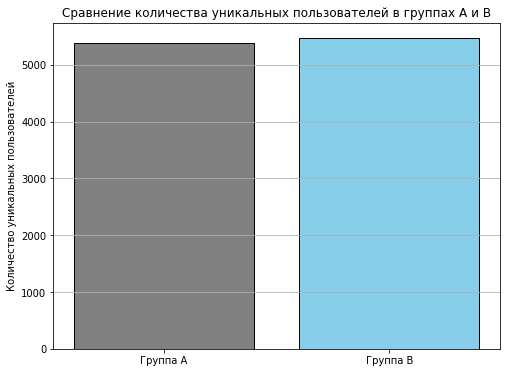

In [51]:
# Строим столбчатую диаграмму для визуализации различия между группами
plt.figure(figsize=(8, 6))

groups = ['Группа A', 'Группа B']
counts = [group_a_count, group_b_count]

plt.bar(groups, counts, color=['grey', 'skyblue'], edgecolor='black')
plt.ylabel('Количество уникальных пользователей')
plt.title('Сравнение количества уникальных пользователей в группах A и B')
plt.grid(axis='y')

plt.show()

In [52]:
# Проверяем пересечения пользователей между группами
group_a = interface_df[interface_df['group'] == 'A']['user_id']
group_b = interface_df[interface_df['group'] == 'B']['user_id']

intersection = list(set(group_a) & set(group_b))

display(f'Количество пользователей одновременно в группах A и B: {intersection}')

'Количество пользователей одновременно в группах A и B: []'

In [68]:
# Код ревьюера (начну с начала для наглядности)
participants1 = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events1 = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

interface_df1 = participants1.merge(events1, on='user_id', how='left')
# Группирую по группам
user_groups1 = interface_df1.groupby('user_id')['ab_test'].unique()

# ищу тех у кого два теста
overlap_users = user_groups1[user_groups1.apply(len) > 1]
print(overlap_users)

user_id
001064FEAAB631A1    [recommender_system_test, interface_eu_test]
00341D8401F0F665    [recommender_system_test, interface_eu_test]
0082295A41A867B5    [interface_eu_test, recommender_system_test]
00E68F103C66C1F7    [recommender_system_test, interface_eu_test]
00EFA157F7B6E1C4    [interface_eu_test, recommender_system_test]
                                        ...                     
FEA0C585A53E7027    [interface_eu_test, recommender_system_test]
FEC0BCA6C323872F    [recommender_system_test, interface_eu_test]
FF2174A1AA0EAD20    [interface_eu_test, recommender_system_test]
FF44696E39039D29    [interface_eu_test, recommender_system_test]
FFF28D02B1EACBE1    [recommender_system_test, interface_eu_test]
Name: ab_test, Length: 887, dtype: object


Оценим распределение пользователей по устройствам

In [53]:
# Фильтруем данные, оставялем только группу A
group_a_df = interface_df[interface_df['group'] == 'A']

display('Типы устройств группы A:')

# Посчитаем количество и долю пользователей по устройствам
count_a_device = group_a_df.groupby('device')['user_id'].nunique()
total_a_device = group_a_df['user_id'].nunique()

shere_a_device = count_a_device/total_a_device

# Создаем отдельный датафрейм с количеством и долей
df_a_device = pd.DataFrame({'Абс_количество':count_a_device,
                            'Отн_количество':shere_a_device})
display(df_a_device)

'Типы устройств группы A:'

,Абс_количество,Отн_количество
device,,
Android,2445,0.454208
Mac,566,0.105146
PC,1346,0.250046
iPhone,1026,0.190600


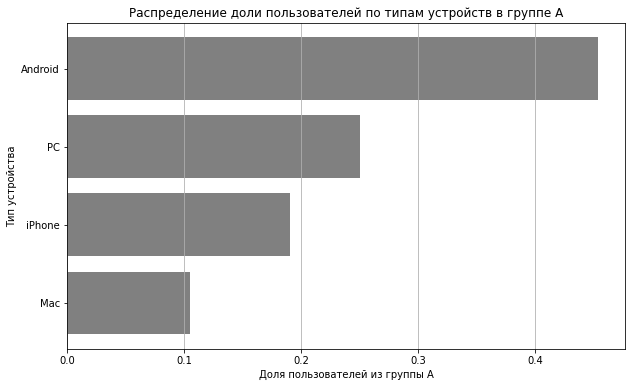

In [54]:
# Строим линейчатую диаграмму для группы A
plt.figure(figsize=(10, 6))

# Сортируем датафрейм по доле пользователей 
df_sorted_a1 = df_a_device.sort_values('Отн_количество', ascending=True)

# index — типы устройств, shere_a — доли 
plt.barh(df_sorted_a1.index, df_sorted_a1['Отн_количество'], color='grey')  

plt.xlabel('Доля пользователей из группы A')
plt.ylabel('Тип устройства')

plt.title('Распределение доли пользователей по типам устройств в группе A')

plt.grid(axis='x')
plt.show()

In [55]:
# Фильтруем данные, оставялем только группу B
group_b_df = interface_df[interface_df['group'] == 'B']

display('Типы устройств группы B:')

# Посчитаем количество и долю пользователей по устройствам
count_b_device = group_b_df.groupby('device')['user_id'].nunique()
total_b_device = group_b_df['user_id'].nunique()

shere_b_device = count_b_device/total_b_device

# Создаем отдельный датафрейм с количеством и долей
df_b_device = pd.DataFrame({'Абс_количество':count_b_device,
                            'Отн_количество':shere_b_device})
display(df_b_device)

'Типы устройств группы B:'

,Абс_количество,Отн_количество
device,,
Android,2414,0.441558
Mac,554,0.101335
PC,1418,0.259374
iPhone,1081,0.197732


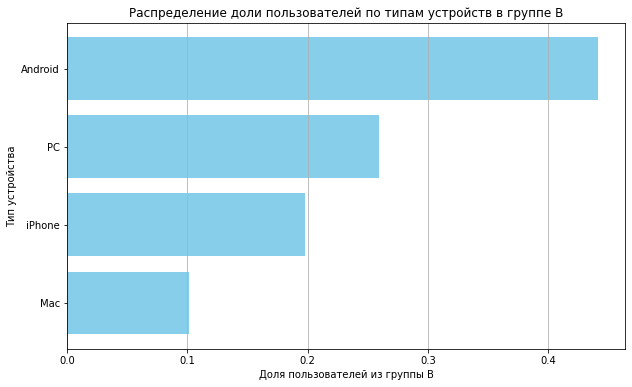

In [56]:
# Строим линейчатую диаграмму для группы B
plt.figure(figsize=(10, 6))

# Сортируем датафрейм по доле пользователей 
df_sorted_b1 = df_b_device.sort_values('Отн_количество', ascending=True)

# index — типы устройств, shere_b — доли (сортируем по убыванию)
plt.barh(df_sorted_b1.index, df_sorted_b1['Отн_количество'], color='skyblue')  

plt.xlabel('Доля пользователей из группы B')
plt.ylabel('Тип устройства')

plt.title('Распределение доли пользователей по типам устройств в группе B')

plt.grid(axis='x')
plt.show()

**Заключение по оценке распределения групп:**

* A/B-тест проведен с участием контрольной **A-группы (5383 пользователей)** со старой версией сайта и тестовой **B-группы (5467 пользователей)** с новой версией сайта. **Процентная разница** в количестве пользователей **в группах A и B: 1.56%** допустима для проведения теста. 
* Расчитанное необходимое число участников каждой группы - 3761 пользователь, что соответствует фактическому количеству участников каждой из групп
* **Выборки являются независимыми**, так как в ходе проверки не было выявлено пользователей, входящих в состав обеих групп. 
* В группах **наблюдается равномерное распределение пользователей по устройствам**, что видно на соответствующих диаграммах

In [57]:
interface_df = interface_df.sort_values('event_dt')  # сортируем по дате

# Для каждого пользователя находим первую дату и добавляем 7 дней
first_dates = interface_df.groupby('user_id')['event_dt'].transform('first') + pd.to_timedelta('7D')

# Фильтруем: оставляем только события в пределах 7 дней с первого события каждого пользователя
interface_df = interface_df[interface_df['event_dt'] <= first_dates]

In [58]:
interface_df.head()

,user_id,group,ab_test,device,event_dt,event_name,details
39061,5F506CEBEDC05D30,A,interface_eu_test,iPhone,2020-12-06 14:10:01,registration,0.0
33373,51278A006E918D97,A,interface_eu_test,Android,2020-12-06 14:37:25,registration,-3.8
65870,A0C1E8EFAD874D8B,B,interface_eu_test,iPhone,2020-12-06 17:20:22,registration,-3.32
15753,275A8D6254ACF530,A,interface_eu_test,iPhone,2020-12-06 19:36:54,registration,-0.48
4565,0B704EB2DC7FCA4B,B,interface_eu_test,PC,2020-12-06 19:42:20,registration,0.0


In [59]:
interface_df['event_name'].unique()

array(['registration', 'login', 'product_page', 'purchase',
       'product_cart'], dtype=object)

In [60]:
# Находим количество уникальных пользователей в группe A
group_a_count = interface_df[interface_df['group'] == 'A']['user_id'].nunique()

# Фильтруем данные, оставялем только группу A
group_a_df = interface_df[interface_df['group'] == 'A']

# Находим количество уникальных пользователей, совершивших покупку в группe A
buyers_a_count = group_a_df[group_a_df['event_name']=='purchase']['user_id'].nunique()

display(f'Группа A: всего {group_a_count} посетителей, из них {buyers_a_count} покупателей')

'Группа A: всего 5383 посетителей, из них 1480 покупателей'

In [61]:
# Находим количество уникальных пользователей в группe B
group_b_count = interface_df[interface_df['group'] == 'B']['user_id'].nunique()

# Фильтруем данные, оставялем только группу B
group_b_df = interface_df[interface_df['group'] == 'B']

# Находим количество уникальных пользователей, совершивших покупку в группe B
buyers_b_count = group_b_df[group_b_df['event_name']=='purchase']['user_id'].nunique()

display(f'Группа B: всего {group_b_count} посетителей, из них {buyers_b_count} покупателей')

'Группа B: всего 5467 посетителей, из них 1600 покупателей'

In [62]:
# Считаем конверсию (Conversion Rate) в покупателей для группы A

share_a = round(buyers_a_count/group_a_count, 4)
display(f'Конверсия посетителей в покупателей группы A составляет {share_a}')

'Конверсия посетителей в покупателей группы A составляет 0.2749'

In [63]:
# Считаем конверсию (Conversion Rate) в покупателей для группы A

share_b = round(buyers_b_count/group_b_count, 4)
display(f'Конверсия посетителей в покупателей группы B составляет {share_b}')

'Конверсия посетителей в покупателей группы B составляет 0.2927'

In [64]:
rel_diff_conversion = round((share_b - share_a)*100, 4)
abs_diff_conversion = buyers_b_count - buyers_a_count

display(f'Разница в конверсиях составляет {abs_diff_conversion} покупателей или {rel_diff_conversion} %')

'Разница в конверсиях составляет 120 покупателей или 1.78 %'

##### Предварительный вывод

На этапе предварительного расчета метрик, можно замтить, что разница в конверсиях между контрольной и тестовой группами составляет 120 покупателей или 1.78 %. Эта разница является положительной для возможного принятия альтернативной гипотезы, но требует проверку на статистическую значимость. 

## 4. Оценка результатов A/B-тестирования:

##### Формулировка нулевой и альтернативной гипотез

* **Нулевая гипотеза:** В течение семи дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей групп A (контрольная) и B (тестовая) равны.
    
* **Альтернативная гипотеза:** В течение семи дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей группы A (контрольная) меньше конверсии группы B

In [65]:
# Проводим Z-тест пропорций

# Данные для теста
buyers = [buyers_a_count, buyers_b_count]  # число покупателей в группах A и B
users = [group_a_count, group_b_count]    # общее число зарегистрированных пользователей в группах A и B

alpha = 0.05  # уровень значимости

stat_ztest, p_value_ztest = proportions_ztest(buyers, users, alternative='smaller')

# Выводим результаты
print(f"Доля успешных первых сессий (группа A): {round(share_a, 4)}")
print(f"Доля успешных первых сессий (группа B): {round(share_b, 4)}")
print(f"Z‑статистика (отклонение от среднего): {round(stat_ztest, 4)}")

# Интерпретация результата
if p_value_ztest > alpha:
    print(f'p-value = {round(p_value_ztest, 4)} > {alpha}')
    print("Вывод: Различие не является статистически значимым. Не имеем достаточных оснований для отклонения нулевой гипотезы")
else:
    print(f'p-value = {round(p_value_ztest, 4)} < {alpha}')
    print("Вывод: Различие статистически значимо. Отвергаем нулевую гипотезу")

Доля успешных первых сессий (группа A): 0.2749
Доля успешных первых сессий (группа B): 0.2927
Z‑статистика (отклонение от среднего): -2.0474
p-value = 0.0203 < 0.05
Вывод: Различие статистически значимо. Отвергаем нулевую гипотезу


#### Вывод по результатам A/B-тестирования

Для проверки упрощенного интерфейса сайта, был проведен A/B-тест с участием **контрольной A-группы (5383 пользователей) со старым интерфейсом и тестовой B-группы (5467 пользователей) с новым интерфейсом**. Расчитанное необходимое число участников каждой группы - 3761 пользователь, что соответствует фактическому количеству участников каждой из групп. В качестве **целевой метрики** выбрано **увеличение конверсии зарегистрированных пользователей в покупателей** у тестовой группы по сравнению с контрольной. В качестве **статистического теста для проверки результатов A/B-тестирования выбран Z-тест пропорций**.

Значение **p-value оказалось меньше значения уровня статистической значимости, и равно 0.0203**, поэтому в результате теста **нулевая гипотеза была отвергнута**. Это означает, что **на текущих данных удалось обнаружить статистически значимое различие между конверсиями групп A и B**. 

Так как альтернативная гипотеза нашла статистическое подтверждение, можно сказать что **нововведение** в представленном виде на текущих данных **оказалось эффективным**.